# Klasik Makine Öğrenmesi Modelleri + PCA + LDA + XAI (SHAP) Analizi

**Adım 1: Veri setinin yüklenmesi**

In [3]:
import pandas as pd
from sklearn.datasets import load_wine

# 1. Veri setini yükle
wine = load_wine()

# 2. DataFrame oluştur
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# 3. Target ekle
df["target"] = wine.target

# 4. İlk 5 satırı göster
print("İlk 5 satır:")
display(df.head())

# 5. Veri seti boyutu
print("Veri seti boyutu:", df.shape)

# 6. X ve y ayır
X = df.drop("target", axis=1)
y = df["target"]

# 7. Kontrol
print("\nX boyutu:", X.shape)
print("y boyutu:", y.shape)

# 8. Sınıf bilgisi
print("\nSınıf sayısı:", y.nunique())
print("Sınıflar:", y.unique())

İlk 5 satır:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Veri seti boyutu: (178, 14)

X boyutu: (178, 13)
y boyutu: (178,)

Sınıf sayısı: 3
Sınıflar: [0 1 2]


**Adım 2: Veri seti kalite kontrolleri**

In [4]:
# Eksik değer kontrolü
print("Her sütundaki eksik değer sayısı:\n")
print(df.isnull().sum())

# Veri tipleri
print("\nSütunların veri tipleri:\n")
print(df.dtypes)

# Sayısal ve kategorik değişken sayısı
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

print("\nSayısal değişken sayısı:", len(numerical_cols))
print("Kategorik değişken sayısı:", len(categorical_cols))

Her sütundaki eksik değer sayısı:

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Sütunların veri tipleri:

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od3

*Aykırı değer analizi — IQR yöntemi*

In [5]:
Q1 = df.drop("target", axis=1).quantile(0.25)
Q3 = df.drop("target", axis=1).quantile(0.75)
IQR = Q3 - Q1

outlier_counts = ((df.drop("target", axis=1) < (Q1 - 1.5 * IQR)) |
                  (df.drop("target", axis=1) > (Q3 + 1.5 * IQR))).sum()

print("Her özellik için aykırı değer sayısı:\n")
print(outlier_counts)

outlier_rows = ((df.drop("target", axis=1) < (Q1 - 1.5 * IQR)) |
                (df.drop("target", axis=1) > (Q3 + 1.5 * IQR))).any(axis=1)

print("En az bir aykırı değer içeren satır sayısı:", outlier_rows.sum())

Her özellik için aykırı değer sayısı:

alcohol                         0
malic_acid                      3
ash                             3
alcalinity_of_ash               4
magnesium                       4
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 2
color_intensity                 4
hue                             1
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64
En az bir aykırı değer içeren satır sayısı: 17


**Adım 3: EDA (istatistik + heatmap + boxplot)**

*3.1 İstatistiksel özellikler*

In [6]:
print(df.describe().T)

                              count        mean         std     min       25%  \
alcohol                       178.0   13.000618    0.811827   11.03   12.3625   
malic_acid                    178.0    2.336348    1.117146    0.74    1.6025   
ash                           178.0    2.366517    0.274344    1.36    2.2100   
alcalinity_of_ash             178.0   19.494944    3.339564   10.60   17.2000   
magnesium                     178.0   99.741573   14.282484   70.00   88.0000   
total_phenols                 178.0    2.295112    0.625851    0.98    1.7425   
flavanoids                    178.0    2.029270    0.998859    0.34    1.2050   
nonflavanoid_phenols          178.0    0.361854    0.124453    0.13    0.2700   
proanthocyanins               178.0    1.590899    0.572359    0.41    1.2500   
color_intensity               178.0    5.058090    2.318286    1.28    3.2200   
hue                           178.0    0.957449    0.228572    0.48    0.7825   
od280/od315_of_diluted_wines

*3.2 Korelasyon matrisi (HEATMAP)*

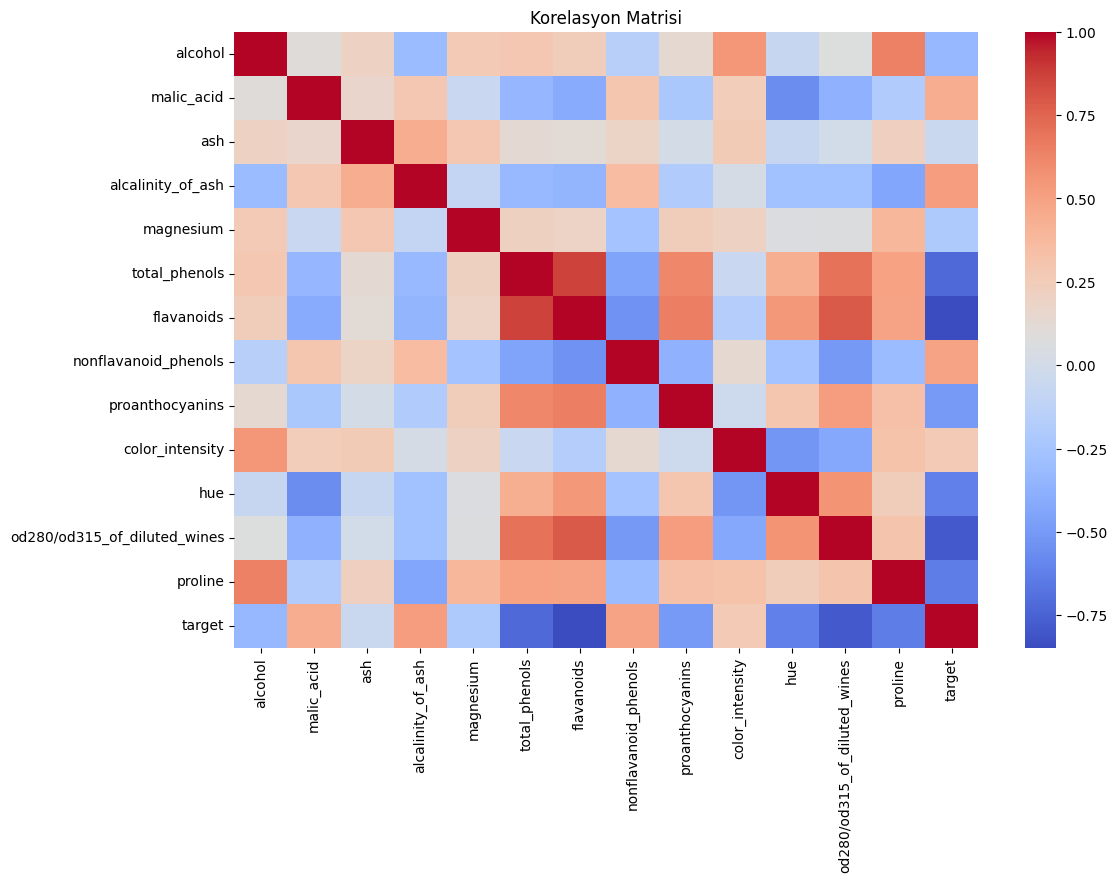

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()

*3.3 Boxplot*

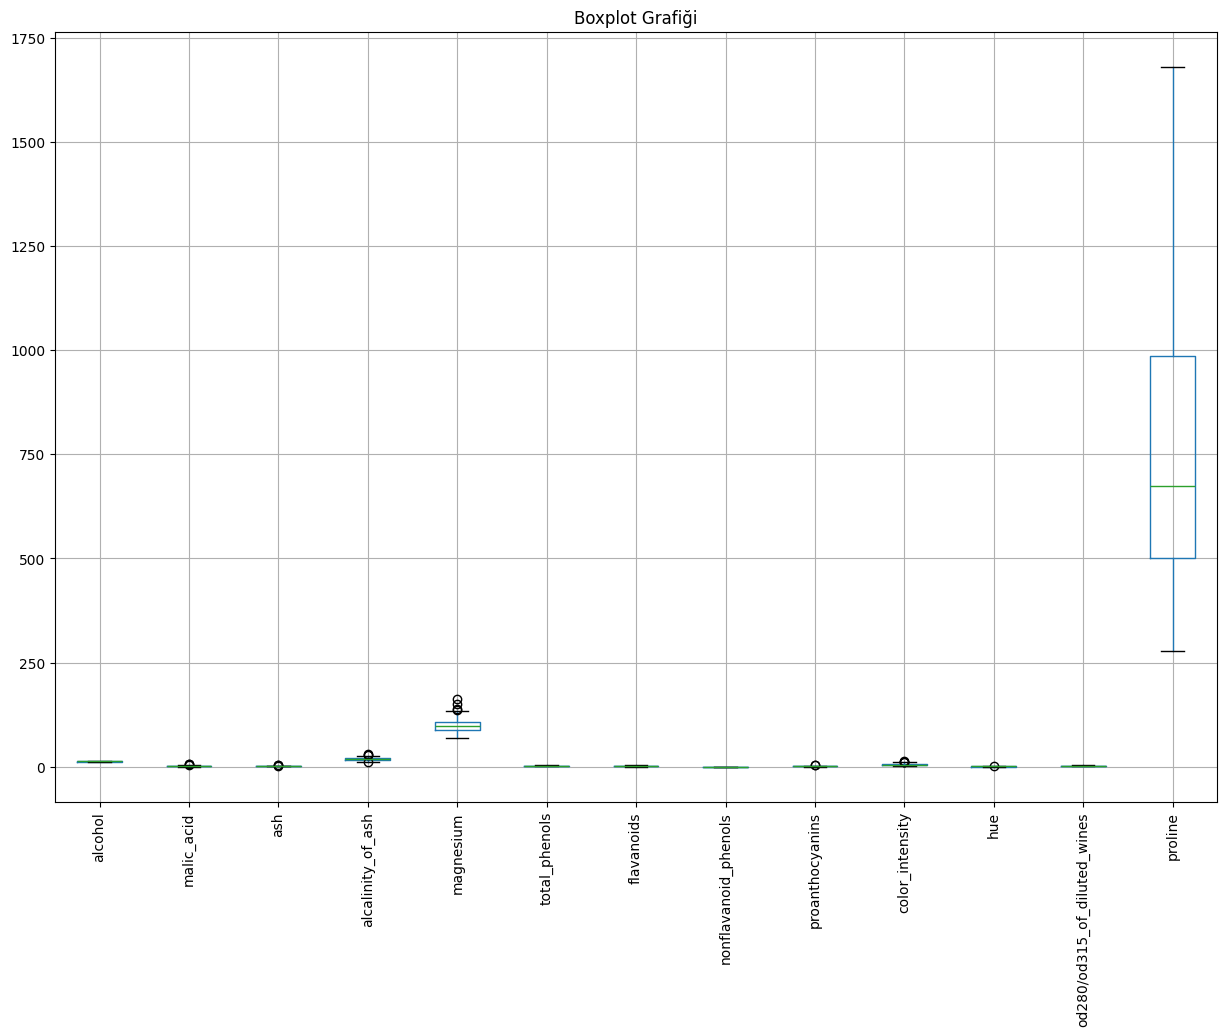

In [10]:
plt.figure(figsize=(15,10))
df.drop("target", axis=1).boxplot()
plt.xticks(rotation=90)
plt.title("Boxplot Grafiği")
plt.show()

**Adım 4: Veri Setinin Bölünmesi**

In [11]:
from sklearn.model_selection import train_test_split

# ham veriyi böl
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.66, random_state=42, stratify=y_temp
)

print("Train:", X_train_raw.shape)
print("Validation:", X_val_raw.shape)
print("Test:", X_test_raw.shape)

Train: (124, 13)
Validation: (18, 13)
Test: (36, 13)


**Adım 5: Scaling**

In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# sadece train üzerinde fit
X_train = scaler.fit_transform(X_train_raw)

# val ve test sadece transform
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# DataFrame'e çevir
X_train = pd.DataFrame(X_train, columns=X.columns, index=X_train_raw.index)
X_val = pd.DataFrame(X_val, columns=X.columns, index=X_val_raw.index)
X_test = pd.DataFrame(X_test, columns=X.columns, index=X_test_raw.index)

display(X_train.head())
print(X_train.describe().T)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
12,0.982686,-0.527640,0.173598,-1.087543,-0.727661,0.491455,0.791460,-0.596717,0.354587,0.255419,0.857462,0.437825,1.863180
30,0.957937,-0.745511,1.255504,0.839386,0.063252,1.131923,1.306553,-0.596717,1.343233,0.297587,1.032095,0.159563,1.749108
36,0.401078,-0.612894,1.777803,-1.235769,0.656436,0.491455,0.707363,-0.170491,-0.425924,-0.166255,0.595512,0.262081,0.429136
31,0.772317,-0.593949,-0.012937,-0.168547,0.392799,0.907759,1.243480,-1.193434,0.597412,0.803596,0.595512,0.408534,2.498722
120,-1.863482,0.107025,0.210905,0.098259,-0.266295,0.971806,0.822996,-0.340981,0.389276,-0.735516,-0.670576,1.155447,-0.401958


                              count          mean       std       min  \
alcohol                       124.0  3.086241e-15  1.004057 -2.383217   
malic_acid                    124.0  3.232182e-16  1.004057 -1.465430   
ash                           124.0  2.290283e-15  1.004057 -3.743645   
alcalinity_of_ash             124.0  1.248106e-15  1.004057 -2.688377   
magnesium                     124.0 -3.959821e-16  1.004057 -1.979940   
total_phenols                 124.0  1.378825e-16  1.004057 -2.102437   
flavanoids                    124.0  2.533815e-16  1.004057 -1.752470   
nonflavanoid_phenols          124.0 -1.271384e-15  1.004057 -1.960642   
proanthocyanins               124.0  2.070029e-15  1.004057 -2.056322   
color_intensity               124.0 -3.312762e-16  1.004057 -1.566215   
hue                           124.0  5.440317e-16  1.004057 -2.067640   
od280/od315_of_diluted_wines  124.0  1.237361e-15  1.004057 -1.949367   
proline                       124.0 -1.262431e-16  

**Adım 6: PCA**

Seçilen PCA bileşen sayısı: 3


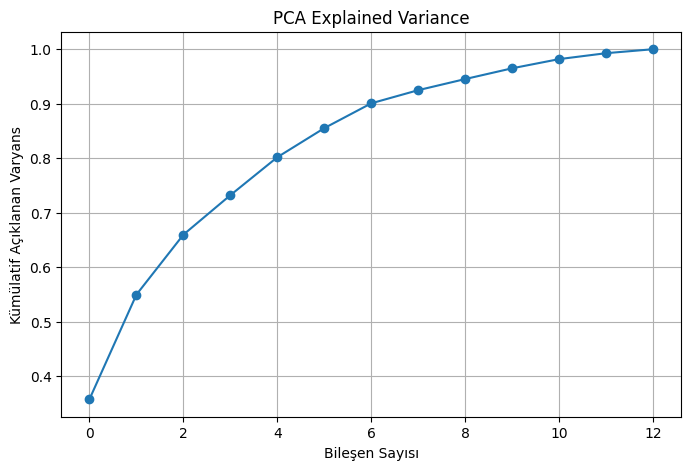

Train: (124, 3)
Validation: (18, 3)
Test: (36, 3)


In [13]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# sadece train üzerinde fit
pca_full = PCA()
pca_full.fit(X_train)

explained = pca_full.explained_variance_ratio_

# component seçimi
threshold = explained.mean()
n_components = np.sum(explained > threshold)

print("Seçilen PCA bileşen sayısı:", n_components)

# grafik
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained), marker='o')
plt.xlabel("Bileşen Sayısı")
plt.ylabel("Kümülatif Açıklanan Varyans")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

# PCA dönüşüm
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print("Train:", X_train_pca.shape)
print("Validation:", X_val_pca.shape)
print("Test:", X_test_pca.shape)

**Adım 6.2: LDA**

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)

# sadece train üzerinde fit
X_train_lda = lda.fit_transform(X_train, y_train)

# val ve test'e transform
X_val_lda = lda.transform(X_val)
X_test_lda = lda.transform(X_test)

print("Train:", X_train_lda.shape)
print("Validation:", X_val_lda.shape)
print("Test:", X_test_lda.shape)

Train: (124, 2)
Validation: (18, 2)
Test: (36, 2)


*Scatter*

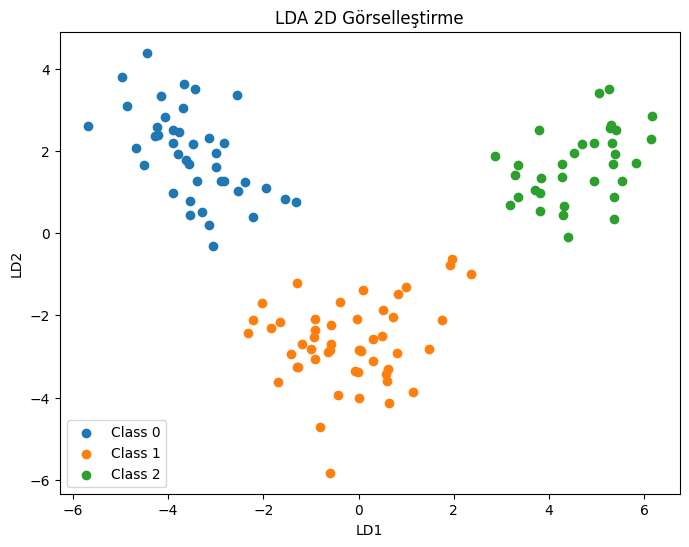

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

for i in np.unique(y_train):
    plt.scatter(
        X_train_lda[y_train == i, 0],
        X_train_lda[y_train == i, 1],
        label=f"Class {i}"
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA 2D Görselleştirme")
plt.legend()
plt.show()

**Adım 7: Model**

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, data_type):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)

    results.append({
        "Model": name,
        "Data": data_type,
        "Accuracy": accuracy_score(y_v, y_pred),
        "Precision": precision_score(y_v, y_pred, average="weighted"),
        "Recall": recall_score(y_v, y_pred, average="weighted"),
        "F1": f1_score(y_v, y_pred, average="weighted")
    })

# RAW
for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_val, y_val, "Raw")

# PCA
for name, model in models.items():
    evaluate_model(name, model, X_train_pca, y_train, X_val_pca, y_val, "PCA")

# LDA
for name, model in models.items():
    evaluate_model(name, model, X_train_lda, y_train, X_val_lda, y_val, "LDA")

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(results_df)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:05:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:05:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:05:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Data,Accuracy,Precision,Recall,F1
0,Logistic Regression,Raw,1.000000,1.000000,1.000000,1.000000
2,Random Forest,Raw,1.000000,1.000000,1.000000,1.000000
3,XGBoost,Raw,1.000000,1.000000,1.000000,1.000000
5,Logistic Regression,PCA,1.000000,1.000000,1.000000,1.000000
4,Naive Bayes,Raw,1.000000,1.000000,1.000000,1.000000
10,Logistic Regression,LDA,1.000000,1.000000,1.000000,1.000000
9,Naive Bayes,PCA,0.944444,0.951389,0.944444,0.943771
13,XGBoost,LDA,0.944444,0.951389,0.944444,0.943210
14,Naive Bayes,LDA,0.944444,0.951389,0.944444,0.943210
12,Random Forest,LDA,0.944444,0.952381,0.944444,0.944444


**Adım 8: En İyi Model + Test**

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import shap
import numpy as np


# modeli tekrar eğit
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# test tahmini
y_pred = model.predict(X_test)

*Confusion Matrix*

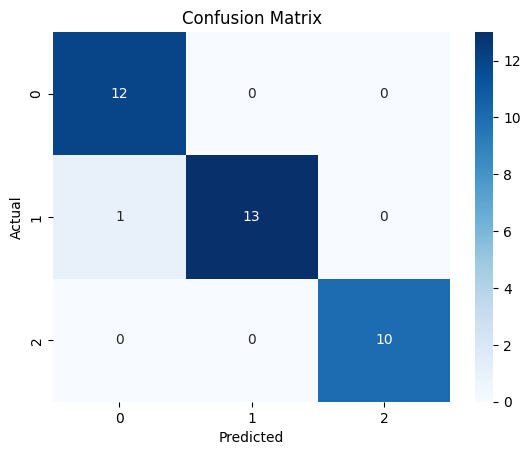

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

*ROC Curve (multi-class)*

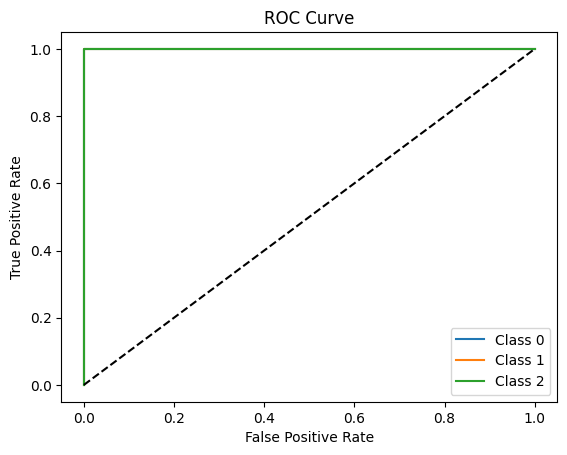

In [18]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = model.predict_proba(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**SHAP (XAI)**

In [19]:
import shap
import numpy as np

# explainer
explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test)

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(36, 13, 3)


*Summary plot*

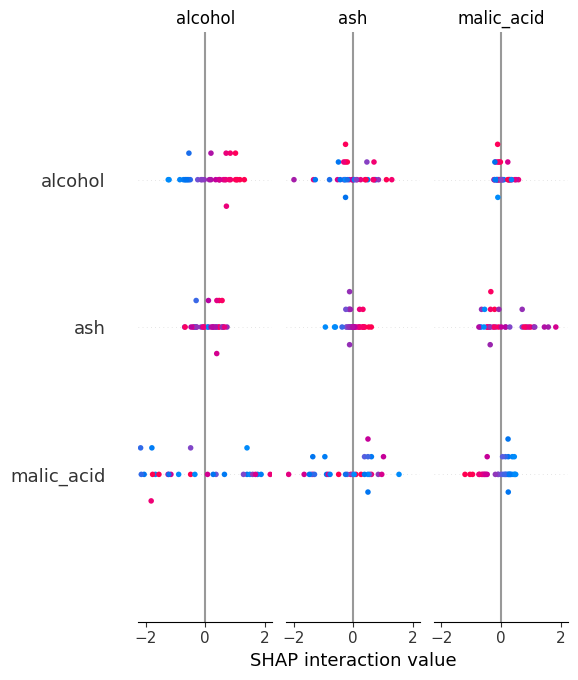

In [20]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

*Bar plot*

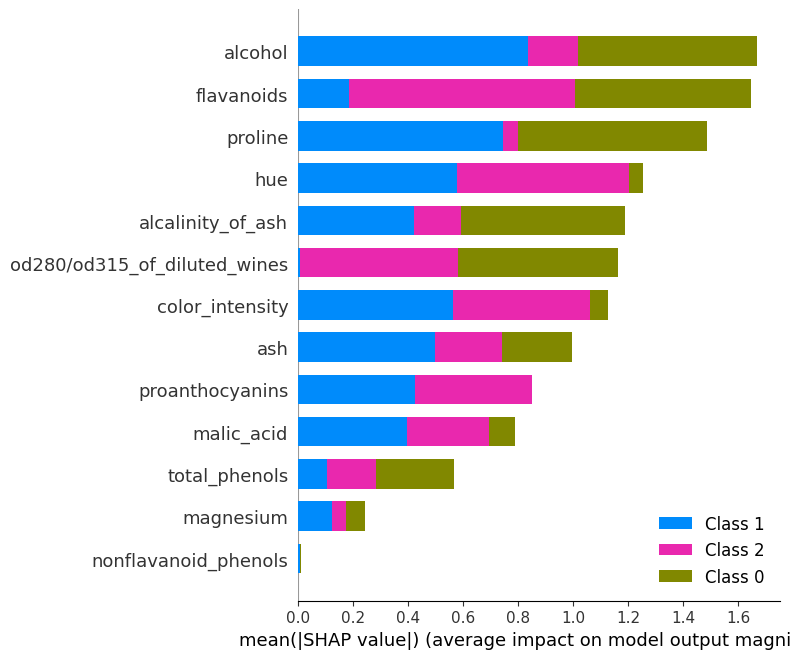

In [21]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type="bar")